In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2A!

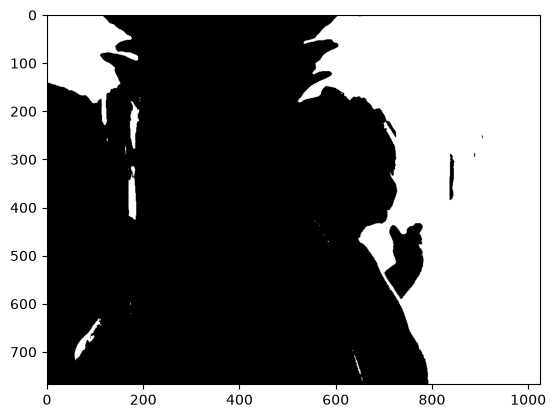

In [25]:
import cv2
import numpy as np

img = cv2.imread("img/foto06.jpg", cv2.IMREAD_GRAYSCALE)
assert img is not None
h, w = img.shape
limiar_img = np.full(shape=img.shape, fill_value=0, dtype=np.uint8)

# limiar = int(input("digite o limiar\n"))
# tirando a interatividade ja que tamo juntando num ipynb

limiar = 128

limiar = max(0, min(255, limiar))
limiar_img = np.where(img>limiar, 255, 0).astype(np.uint8)
#cv2.imwrite("output/limiar.jpg", limiar_img)

plt.imshow(limiar_img, cmap='gray')

## 2B!

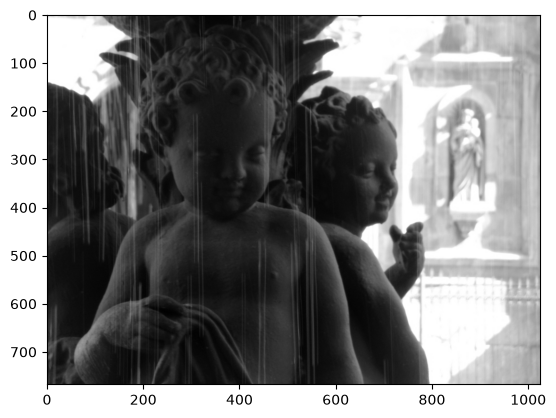

In [26]:
a = cv2.imread("img/foto06.jpg", flags=cv2.IMREAD_GRAYSCALE)

plt.imshow(a, cmap='gray')


In [27]:

logclaro = np.zeros((a.shape[0], a.shape[0]))
# logescuro = cv2.log()

c = 1

logclaro = c * np.log1p(a)
logescuro = 1.01 ** a


mini = np.min(logclaro)
maxi = np.max(logclaro)
print(mini)
print(maxi)

# print(logescuro)

mini1 = np.min(logescuro)
maxi1 = np.max(logescuro)

print(np.max(logescuro))
print(np.min(logescuro))



2.564
5.547
12.645916636849323
1.1268250301319698


In [28]:
# print(logclaro)

for i in range(logclaro.shape[0]):
    for j in range(logclaro.shape[1]):
        logclaro[i][j] = int((logclaro[i][j] - mini) * (255/(maxi-mini)))

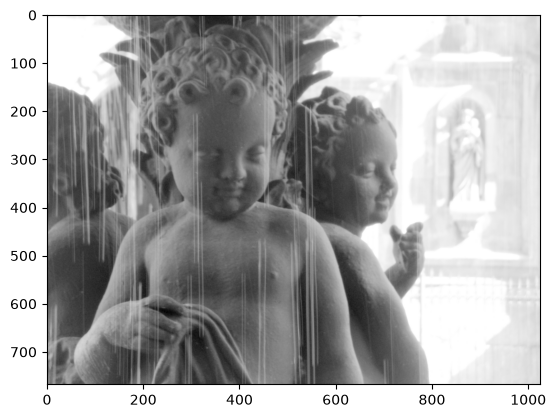

In [29]:
plt.imshow(logclaro, cmap='gray')

In [30]:
for i in range(logescuro.shape[0]):
    for j in range(logescuro.shape[1]):
        logescuro[i][j] = int((logescuro[i][j] - mini1) * (255/(maxi1-mini1)))

[[172. 172. 176. ... 105. 106. 107.]
 [182. 180. 180. ... 106. 107. 107.]
 [186. 186. 189. ... 107. 107. 109.]
 ...
 [ 14.  15.  15. ...  84.  84.  83.]
 [ 15.  16.  15. ...  83.  83.  81.]
 [ 15.  15.  16. ...  79.  79.  79.]]
254.0


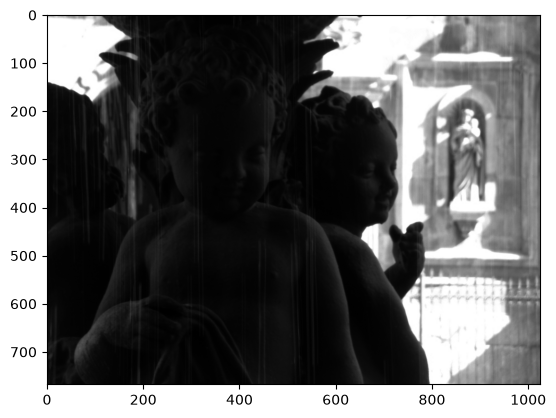

In [31]:
plt.clf()
print(logescuro)
plt.imshow(logescuro, cmap='gray')
print(np.max(logescuro))

<Figure size 640x480 with 0 Axes>

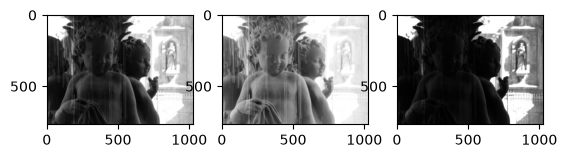

In [32]:
plt.clf()
_, eu = plt.subplots(1, 3)

eu[0].imshow(a, cmap='gray')
eu[1].imshow(logclaro, cmap='gray')
eu[2].imshow(logescuro, cmap='gray')

plt.show()


## 2C!

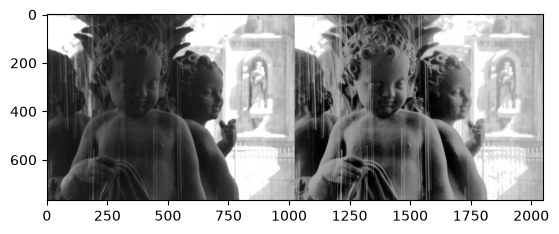

In [33]:
img = cv2.imread("img/foto06.jpg", cv2.IMREAD_GRAYSCALE)
assert img is not None
h, w = img.shape

output_img = np.full((h,2*w), 255, np.uint8)

histogram = [0 for _ in range(256)]
histogram_div = h*w

for i in range(h):
    for j in range(w):
        histogram[img[i][j]]+=1 

for i in range(256):
    histogram[i] = histogram[i]/histogram_div

histacc = [0 for _ in range(256)]

for i in range(1, 256):
    histacc[i] = histacc[i-1]+histogram[i]
manual_histogram = img.copy()
for i in range(h):
    for j in range(w):
        manual_histogram[i][j] = (255*(histacc[manual_histogram[i][j]]))
output_img = np.hstack([img, manual_histogram])
# cv2.imwrite("output/side_by_side.jpg", output_img)

plt.imshow(output_img, cmap='gray')

## 2D!

(35, 45, 3)
(450, 350, 3)
(350, 900, 3)
(350, 900, 3)
(350, 450, 3)
final shapes:

(350, 450, 3)
(350, 450, 3)
(350, 450, 3)
(350, 450, 3)


<Figure size 640x480 with 0 Axes>

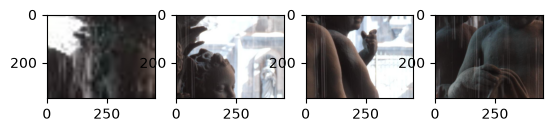

In [34]:
a = cv2.imread("img/a.jpg")
b = cv2.imread("img/b.jpg")
c = cv2.imread("img/c.jpg")
d = cv2.imread("img/d.jpg")

print(a.shape)
print(b.shape)
print(c.shape)
print(d.shape)

a = cv2.resize(a, (10*a.shape[1], 10*a.shape[0]))

b = np.rot90(b)

c = c[:,:int(c.shape[1]/2), :]

print(c.shape)


d = d[:, int(d.shape[1]/2):, :]

print("final shapes:\n")

print(a.shape)
print(b.shape)
print(c.shape)
print(d.shape)

plt.imshow(d)

plt.clf()
_, eu = plt.subplots(1, 4)
eu[0].imshow(a)
eu[1].imshow(b)
eu[2].imshow(c)
eu[3].imshow(d)


<Figure size 640x480 with 0 Axes>

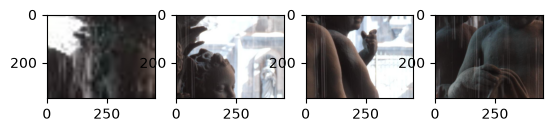

In [35]:
plt.clf()
_, eu = plt.subplots(1, 4)
eu[0].imshow(a)
eu[1].imshow(b)
eu[2].imshow(c)
eu[3].imshow(d)

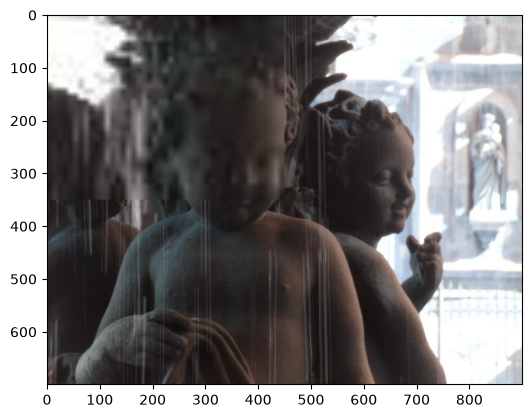

In [36]:
f1 = np.hstack((a, b))
f2 = np.hstack((d, c))
final = np.vstack((f1, f2))

plt.imshow(final)


## 2E!

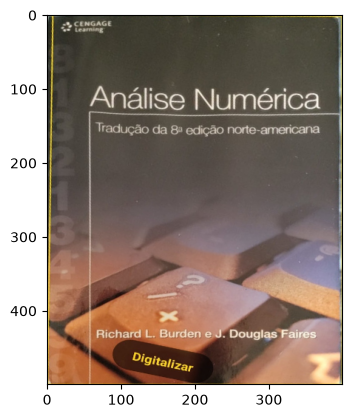

In [37]:
source_coordinates = np.array(
    [
    [52, 122], 
    [473, 27], 
    [663, 653],
    [162, 777],
    ],
       np.float32)
destination_coordinates = np.array([
    [0, 0], 
    [400, 0],
    [400, 500], 
    [0, 500], 
    ], np.float32)

img = cv2.imread("img/livro.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

assert img is not None

transform = cv2.getPerspectiveTransform(src=source_coordinates, dst=destination_coordinates)

a = cv2.warpPerspective(img, transform, (400, 500))

# cv2.imwrite("output/perspective.jpg",a)
plt.imshow(a)